## Conversational Analytics (Intent, Fallback, Confidence, User Behavior)

### Review: 
- Everything we’ve done so far (cleaning, structuring, lemmatizing, simulating intents/confidence) was preparation.
- Let's mvoe on to producing insights, charts, metrics, and patterns

### Goal: Analyze
- Intent distribution
- Fallback rate
- Low-confidence predictions
- User vs company behavior
- Time-based trends
- Conversation-level insights

### Step 1 — Load the dataset

In [102]:
import pandas as pd

df = pd.read_csv("../data/twcs_intent_simulated.csv")
df.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,Clean_text,conversation_id,text_lemma,intent,confidence,is_low_conf,is_fallback,is_user,is_company
0,192624,161253,True,Wed Oct 04 13:59:33 +0000 2017,@161252 What's that egg website people talk about,192623,192625.0,what s that egg website people talk about,192625.0,s egg website people talk,refund_request,0.631970,False,False,True,False
1,738238,296574,True,Fri Oct 06 18:29:06 +0000 2017,Why!🤷🏻‍♀️ #iOS11 @AppleSupport https://t.co/BX...,738237,NaN,why,738238.0,NaN,technical_problem,0.682013,False,False,True,False
2,2414302,AppleSupport,False,Tue Nov 14 17:38:01 +0000 2017,@693975 We can assist you. We recommend updati...,2414303,2414304.0,we can assist you we recommend updating to ios...,2414304.0,assist recommend update io 11 1 1 haven t chan...,account_access,0.891190,False,False,False,True
3,1793929,539096,True,Thu Oct 12 06:04:41 +0000 2017,@331912 @115955 Thats better than having an un...,1793928,1793930.0,thats better than having an unstable connectio...,1793930.0,s well have unstable connection drop 5 20 min,technical_problem,0.433034,True,True,True,False
4,2088018,617376,True,Mon Nov 06 20:30:49 +0000 2017,@VirginAmerica is probably one of the best air...,2088017,NaN,is probably one of the best airlines i ve ever...,2088018.0,probably good airline ve experience,refund_request,0.427244,True,True,True,False


## sanity check - is_user

In [2]:
df["is_user"].value_counts()


is_user
True     2718
False    2282
Name: count, dtype: int64

### Step 2 — Intent Distribution

##### Intent distribution is simply the frequency breakdown of user intents in your conversational dataset.  
It tells you what users are trying to do and how often each intent appears.

### Concise takeaway:  
Intent distribution = **count (or percentage) of each intent label across all messages.**


In [4]:
intent_counts = df['intent'].value_counts()
intent_counts

intent
billing_issue        676
refund_request       640
technical_problem    635
unknown              632
order_status         611
smalltalk            611
account_access       603
general_query        592
Name: count, dtype: int64

### Visualizing intent distribution

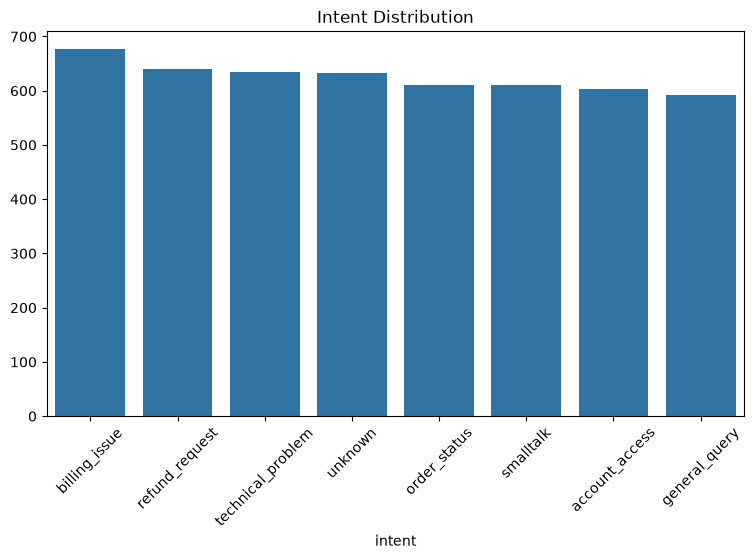

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
sns.barplot(x=intent_counts.index , y= intent_counts.values)
plt.xticks(rotation=45)
plt.title("Intent Distribution")
plt.show()

### Step 3 — Fallback Rate

#### Fallback = bot didn’t understand. or  
`Fallback rate is a core metric in conversational AI that tells you how often your bot fails to understand the user and falls back to a default response.`

#### 🎯 Concise takeaway
**Fallback rate = % of messages where the NLU could not classify the intent confidently.**


### A high fallback rate usually means:
- Users ask things your bot wasn’t trained for
- Your intents are too narrow
- Your NLU model is underperforming
- Your training data is insufficient
- Your bot is receiving noisy or ambiguous messages

### A low fallback rate means:
- Your bot understands users well
- Your intents cover the domain
- Your NLU confidence is strong

### Interpretation:
- < 10% → good
- 10–20% → needs improvement
- 20% → major issues
This metric is critical for chatbot performance.

-----------------------------------------------------------------------

**Note:** Value.count(normalize =True) :  the keyword normalize=True tells pandas:

“Instead of raw counts, give me proportions (i.e., percentages).”

#### EX: 
**Without normalize:**
```
df['is_fallback'].value_counts()
```
→ raw counts
→ how many times each value appears.

**With normalize:**
```
df['is_fallback'].value_counts(normalize=True)
```
→ proportions
→ each count divided by total rows.

In [34]:
fallback_rate  = df['is_fallback'].mean()*100
fallback_rate

np.float64(41.68)

In [33]:
fallback = df['is_fallback'].value_counts(normalize=True) #
fallback

is_fallback
False    0.5832
True     0.4168
Name: proportion, dtype: float64

In [31]:
fbk = df['is_fallback'].mean()*100
fbk

np.float64(41.68)

### Visualization of fallback rate

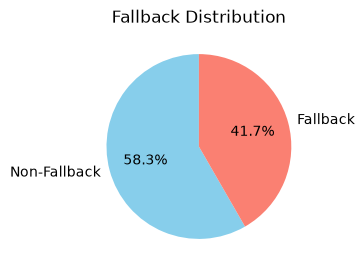

In [37]:
import matplotlib.pyplot as plt

counts = df['is_fallback'].value_counts()

plt.figure(figsize=(3,3))
plt.pie(counts, labels=['Non-Fallback', 'Fallback'], autopct='%1.1f%%', 
        colors=['skyblue', 'salmon'], startangle=90)
plt.title('Fallback Distribution')
plt.show()


### Step 4 — Low-Confidence Analysis

** how often NLU model is unsure about the user’s message, even if it does predict an intent.**

**Concise takeaway : It is the percentage of messages where the model assigned an intent, but the confidence score was below your threshold (commonly 0.5, 0.6, or 0.7).**

##### In other words:
- The model guessed an intent, but wasn’t confident enough.

#### This is different from fallback:
- Fallback → model could not classify
- Low confidence → model classified, but weakly  
Both matter for NLU quality.

In [56]:
# Total low confidance by intent
low_conf_byIntent_count = df.groupby("intent")["is_low_conf"].sum() # sum returns only 'true' count
low_conf_byIntent_count

intent
account_access       210
billing_issue        240
general_query        191
order_status         196
refund_request       204
smalltalk            196
technical_problem    215
unknown              220
Name: is_low_conf, dtype: int64

In [49]:
# average low confidance by intent 
low_conf_byIntent_mean = df.groupby("intent")["is_low_conf"].mean().sort_values(ascending=False)*100
low_conf_byIntent_mean

intent
billing_issue        35.502959
account_access       34.825871
unknown              34.810127
technical_problem    33.858268
general_query        32.263514
order_status         32.078560
smalltalk            32.078560
refund_request       31.875000
Name: is_low_conf, dtype: float64

### Visualize average low confidance Rate by intent
#### Interpretation:
High low-confidence → model unsure  
Often indicates overlapping intents  Or missing training data  Or poorly defined taxonomy

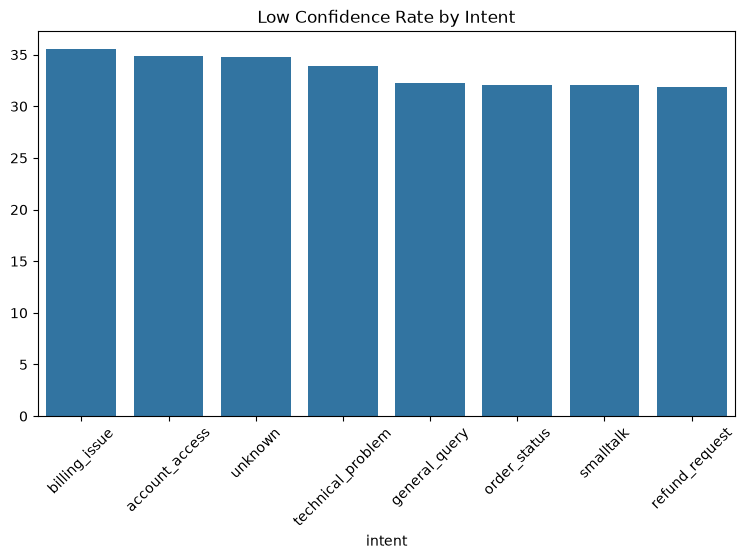

In [50]:
plt.figure(figsize=(9,5))
sns.barplot(x=low_conf_byIntent_mean.index, y=low_conf_byIntent_mean.values)
plt.xticks(rotation=45)
plt.title("Low Confidence Rate by Intent")
plt.show()


### Step 5 — User vs Company Behavior

#### Intent distribution by User and comapany
**Classificcation of messages between user and the company**
- `How many messages come from customers?`
- How many responses does each intent get from the company?


#### Why this matters:
- Customers talk about certain intents more
- Companies respond differently
- Helps identify mismatches
- Helps improve bot training




In [51]:
# percentage of user messages 
df["is_user"].value_counts(normalize=True)

is_user
True     0.5436
False    0.4564
Name: proportion, dtype: float64

In [61]:
user_by_intent = df.groupby('intent')['is_user'].sum().sort_values(ascending=False) # returns total true values
user_by_intent

intent
technical_problem    372
smalltalk            358
billing_issue        352
order_status         335
refund_request       335
account_access       330
unknown              326
general_query        310
Name: is_user, dtype: int64

In [62]:
# or use 
user_intent_counts = df[df["is_user"]]["intent"].value_counts().sort_values(ascending=False) # df[df["is_user"]] keeps only the rows where is_user == True.
user_intent_counts


intent
technical_problem    372
smalltalk            358
billing_issue        352
refund_request       335
order_status         335
account_access       330
unknown              326
general_query        310
Name: count, dtype: int64

### Company response behavior by intent:



In [63]:
company_intent_counts = df[df["is_company"]]["intent"].value_counts()
company_intent_counts


intent
billing_issue        324
unknown              306
refund_request       305
general_query        282
order_status         276
account_access       273
technical_problem    263
smalltalk            253
Name: count, dtype: int64

### Visualization: Side‑by‑Side Bar Chart :User vs Company Response Behavior

#### This tells us:
- which intents are user‑heavy
- which are company‑heavy
- where conversations are balanced

In [66]:
user_vs_company = pd.DataFrame({"company": company_intent_counts,
                                "user":user_intent_counts
                               }).sort_index()
user_vs_company

,company,user
intent,,
account_access,273,330
billing_issue,324,352
general_query,282,310
order_status,276,335
refund_request,305,335
smalltalk,253,358
technical_problem,263,372
unknown,306,326


<Figure size 1000x500 with 0 Axes>

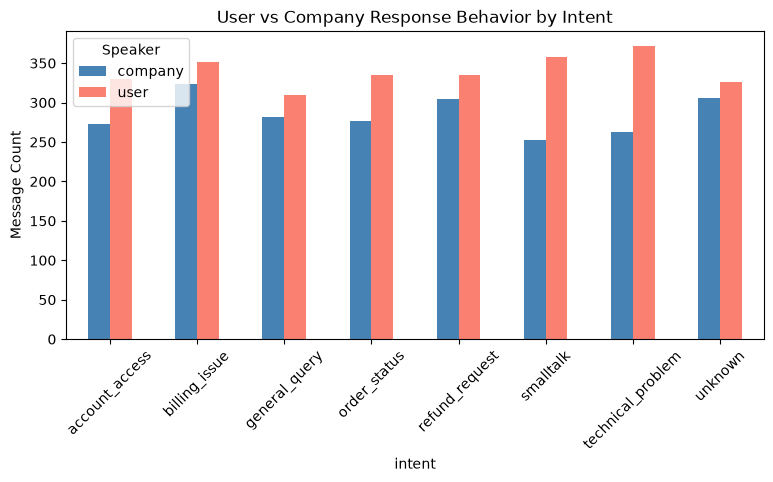

In [77]:
# Plot
plt.figure(figsize=(10,5))
user_vs_company.plot(kind="bar", figsize=(9,4), color=["steelblue", "salmon"])

plt.title("User vs Company Response Behavior by Intent")
plt.ylabel("Message Count")
plt.xticks(rotation=45)
plt.legend(title="Speaker")

plt.show()

### Percentage distribution per intent:

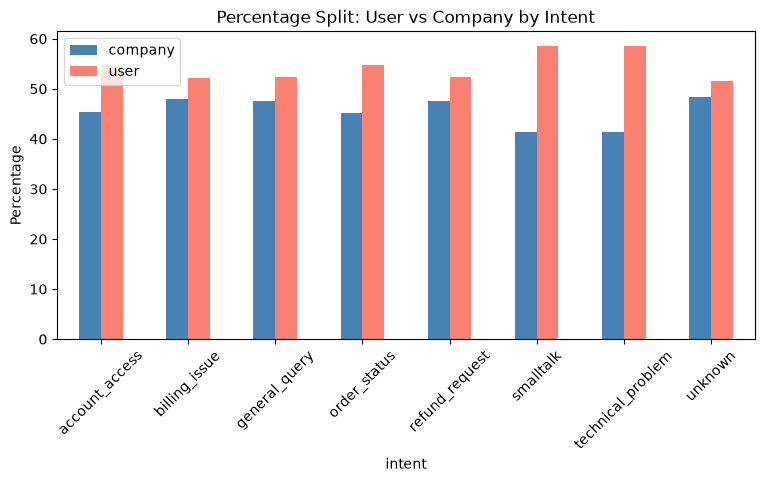

In [73]:
percent = user_vs_company.div(user_vs_company.sum(axis=1), axis=0) * 100

percent.plot(kind="bar", figsize=(9,4), color=["steelblue", "salmon"])
plt.title("Percentage Split: User vs Company by Intent")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()


### Step 6 — Time-Based Trends
**Time‑Based Trends are one of the most important parts of conversational analytics. They tell us how conversation behaviors change over time — instead of looking only at totals or distributions.**

#### Time‑Based Trends = how your conversational metrics change over time.

#####  They help us understand:
- patterns
- anomalies
- seasonality
- model drift
- user behavior changes
- operational load


### Time‑based trends show how a metric evolves across a timeline such as:
- daily, weekly, monthly, hourly, by quarter, by season

#### It answers questions like:
- Are fallbacks increasing over time
- Do users ask more billing questions at month‑end
- Does technical_problem spike after product releases
- Are company responses slower on weekends
- Is low‑confidence rate improving as you retrain your NLU   
It’s about patterns over time, not just static counts.

In [103]:
# regenerate data frame
df.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,Clean_text,conversation_id,text_lemma,intent,confidence,is_low_conf,is_fallback,is_user,is_company
0,192624,161253,True,Wed Oct 04 13:59:33 +0000 2017,@161252 What's that egg website people talk about,192623,192625.0,what s that egg website people talk about,192625.0,s egg website people talk,refund_request,0.631970,False,False,True,False
1,738238,296574,True,Fri Oct 06 18:29:06 +0000 2017,Why!🤷🏻‍♀️ #iOS11 @AppleSupport https://t.co/BX...,738237,NaN,why,738238.0,NaN,technical_problem,0.682013,False,False,True,False
2,2414302,AppleSupport,False,Tue Nov 14 17:38:01 +0000 2017,@693975 We can assist you. We recommend updati...,2414303,2414304.0,we can assist you we recommend updating to ios...,2414304.0,assist recommend update io 11 1 1 haven t chan...,account_access,0.891190,False,False,False,True
3,1793929,539096,True,Thu Oct 12 06:04:41 +0000 2017,@331912 @115955 Thats better than having an un...,1793928,1793930.0,thats better than having an unstable connectio...,1793930.0,s well have unstable connection drop 5 20 min,technical_problem,0.433034,True,True,True,False
4,2088018,617376,True,Mon Nov 06 20:30:49 +0000 2017,@VirginAmerica is probably one of the best air...,2088017,NaN,is probably one of the best airlines i ve ever...,2088018.0,probably good airline ve experience,refund_request,0.427244,True,True,True,False


### Step 6.1 — Convert created_at to timestamp



In [104]:
df['date_time'] = pd.to_datetime(df['created_at'],errors='coerce')
df.head()

C:\Users\divya\AppData\Local\Temp\ipykernel_16404\1711706869.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_time'] = pd.to_datetime(df['created_at'],errors='coerce')


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,Clean_text,conversation_id,text_lemma,intent,confidence,is_low_conf,is_fallback,is_user,is_company,date_time
0,192624,161253,True,Wed Oct 04 13:59:33 +0000 2017,@161252 What's that egg website people talk about,192623,192625.0,what s that egg website people talk about,192625.0,s egg website people talk,refund_request,0.631970,False,False,True,False,2017-10-04 13:59:33+00:00
1,738238,296574,True,Fri Oct 06 18:29:06 +0000 2017,Why!🤷🏻‍♀️ #iOS11 @AppleSupport https://t.co/BX...,738237,NaN,why,738238.0,NaN,technical_problem,0.682013,False,False,True,False,2017-10-06 18:29:06+00:00
2,2414302,AppleSupport,False,Tue Nov 14 17:38:01 +0000 2017,@693975 We can assist you. We recommend updati...,2414303,2414304.0,we can assist you we recommend updating to ios...,2414304.0,assist recommend update io 11 1 1 haven t chan...,account_access,0.891190,False,False,False,True,2017-11-14 17:38:01+00:00
3,1793929,539096,True,Thu Oct 12 06:04:41 +0000 2017,@331912 @115955 Thats better than having an un...,1793928,1793930.0,thats better than having an unstable connectio...,1793930.0,s well have unstable connection drop 5 20 min,technical_problem,0.433034,True,True,True,False,2017-10-12 06:04:41+00:00
4,2088018,617376,True,Mon Nov 06 20:30:49 +0000 2017,@VirginAmerica is probably one of the best air...,2088017,NaN,is probably one of the best airlines i ve ever...,2088018.0,probably good airline ve experience,refund_request,0.427244,True,True,True,False,2017-11-06 20:30:49+00:00


### Step 6.2 — Intent volume by day:
Total intent per day also total messages per day  as 1 message is 1 intent

In [116]:
intent_perday_volume = df.groupby(df['date_time'].dt.date)['intent'].size()
intent_perday_volume.sort_values()

date_time
2015-02-18      1
2016-04-04      1
2016-09-11      1
2017-01-15      1
2017-02-05      1
             ... 
2017-11-02    105
2017-10-11    106
2017-11-27    107
2017-10-27    110
2017-11-07    113
Name: intent, Length: 92, dtype: int64

### Visualize intent/message rate per day

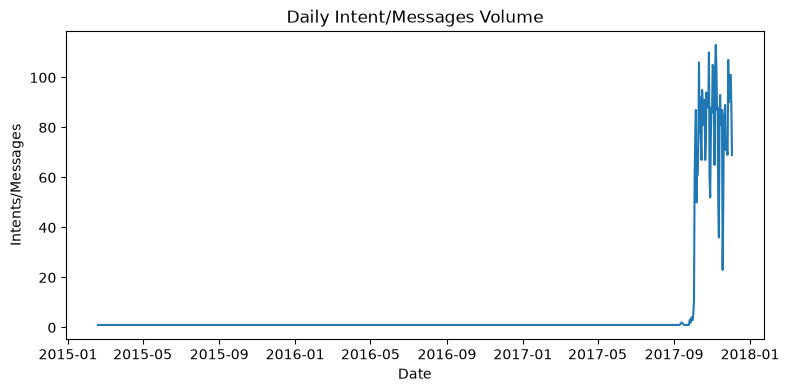

In [117]:
plt.figure(figsize=(9,4))
intent_perday_volume.plot()
plt.title("Daily Intent/Messages Volume")
plt.xlabel("Date")
plt.ylabel("Intents/Messages")
plt.show()

### Step 6.3 — Daily User message volume

In [119]:
user_messages_perDay_count = df[df['is_user']].groupby(df['date_time'].dt.date).size()
user_messages_perDay_count

date_time
2015-02-18     1
2016-09-11     1
2017-02-05     1
2017-07-21     1
2017-07-27     1
              ..
2017-11-29    54
2017-11-30    58
2017-12-01    67
2017-12-02    52
2017-12-03    44
Length: 83, dtype: int64

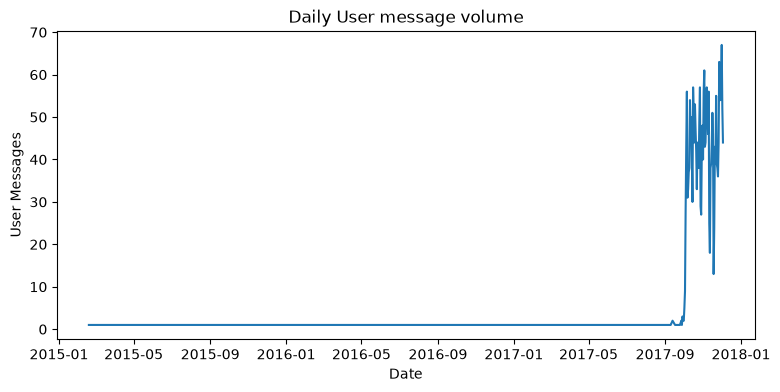

In [115]:
plt.figure(figsize=(9,4))
user_messages_perDay_count.plot()
plt.title("Daily User message volume")
plt.xlabel("Date")
plt.ylabel("User Messages")
plt.show()

### Daily fallback rate

In [120]:
daily_fallback_rate = df.groupby(df['date_time'].dt.date)['is_fallback'].mean()*100
daily_fallback_rate

date_time
2015-02-18    100.000000
2016-04-04      0.000000
2016-09-11      0.000000
2017-01-15      0.000000
2017-02-05      0.000000
                 ...    
2017-11-29     42.553191
2017-11-30     39.603960
2017-12-01     49.504950
2017-12-02     38.202247
2017-12-03     27.536232
Name: is_fallback, Length: 92, dtype: float64

#### Visualize daily fallback rate

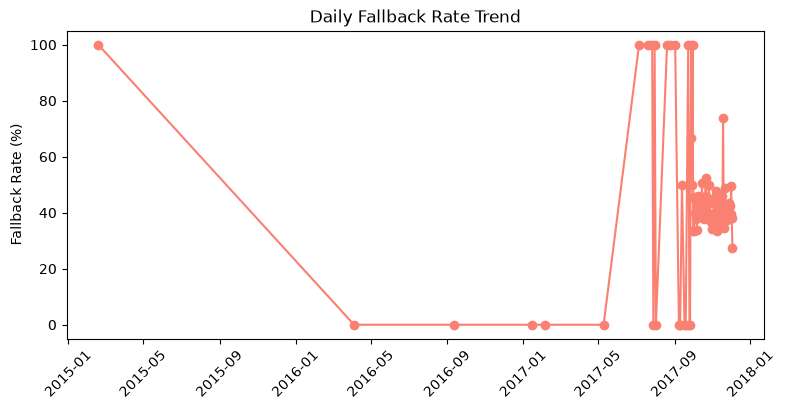

In [121]:
plt.figure(figsize=(9,4))
plt.plot(daily_fallback_rate.index, daily_fallback_rate.values, marker='o', color='salmon')
plt.title("Daily Fallback Rate Trend")
plt.ylabel("Fallback Rate (%)")
plt.xticks(rotation=45)
plt.show()


### Why this matters: Helps make decision with
- Peak support times
- Seasonal trends
- Outages or incidents
- Staffing decisions

### Step 7 — Conversation-Level Insights
-  look beyond individual messages and instead analyze the entire conversation as a unit.

#### They are metrics and patterns that describe how a conversation behaves from start to finish, not just message‑by‑message.

**Instead of asking:** “What is the intent of this message?”  
**Conversation‑level insights ask:** “What happened across the entire conversation?”  

This is the difference between micro‑analysis (message‑level) and macro‑analysis (conversation‑level).

### Identify:
1. Number of messages per conversation
2. long conversations

#### Analysis:
- Long conversations = unresolved issues
- Bot confusion
- Customer frustration
- Training data opportunities


In [122]:
df.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id,Clean_text,conversation_id,text_lemma,intent,confidence,is_low_conf,is_fallback,is_user,is_company,date_time
0,192624,161253,True,Wed Oct 04 13:59:33 +0000 2017,@161252 What's that egg website people talk about,192623,192625.0,what s that egg website people talk about,192625.0,s egg website people talk,refund_request,0.631970,False,False,True,False,2017-10-04 13:59:33+00:00
1,738238,296574,True,Fri Oct 06 18:29:06 +0000 2017,Why!🤷🏻‍♀️ #iOS11 @AppleSupport https://t.co/BX...,738237,NaN,why,738238.0,NaN,technical_problem,0.682013,False,False,True,False,2017-10-06 18:29:06+00:00
2,2414302,AppleSupport,False,Tue Nov 14 17:38:01 +0000 2017,@693975 We can assist you. We recommend updati...,2414303,2414304.0,we can assist you we recommend updating to ios...,2414304.0,assist recommend update io 11 1 1 haven t chan...,account_access,0.891190,False,False,False,True,2017-11-14 17:38:01+00:00
3,1793929,539096,True,Thu Oct 12 06:04:41 +0000 2017,@331912 @115955 Thats better than having an un...,1793928,1793930.0,thats better than having an unstable connectio...,1793930.0,s well have unstable connection drop 5 20 min,technical_problem,0.433034,True,True,True,False,2017-10-12 06:04:41+00:00
4,2088018,617376,True,Mon Nov 06 20:30:49 +0000 2017,@VirginAmerica is probably one of the best air...,2088017,NaN,is probably one of the best airlines i ve ever...,2088018.0,probably good airline ve experience,refund_request,0.427244,True,True,True,False,2017-11-06 20:30:49+00:00


### Step 7.1 — Number of messages per conversation:Convo length

**Check notebook:  04.1_conversation graph**

In [133]:
# Save pdf
df.to_csv("../data/twcs_convo_graph_ready.csv", index=False)